# Teste de Hipótese para a Média Populacional (variância conhecida)

## Enunciado

Uma máquina de envase de refrigerante deve encher garrafas com volume médio de **μ = 355 ml**.
O desvio-padrão do processo é conhecido e igual a **σ = 5 ml**.

Para verificar se a máquina está desregulada, uma amostra aleatória de **n = 36** garrafas foi
coletada, resultando em um volume médio amostral de **x̄ = 353 ml**.

Ao nível de significância de **α = 5%**, há evidência estatística de que a máquina está desregulada?


## 0. Importação das bibliotecas

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt


## 1. Dados do problema

- μ₀ = 355 ml (valor de referência / especificado)
- σ = 5 ml (desvio-padrão populacional, conhecido)
- n = 36 (tamanho da amostra)
- x̄ = 353 ml (média amostral observada)
- α = 0,05 (nível de significância)


In [2]:
mu0 = 355      # média especificada (H0)
sigma = 5      # desvio-padrão populacional (conhecido)
n = 36         # tamanho da amostra
x_bar = 353    # média amostral observada
alpha = 0.05   # nível de significância

print(f"mu0    = {mu0} ml")
print(f"sigma  = {sigma} ml")
print(f"n      = {n}")
print(f"x_bar  = {x_bar} ml")
print(f"alpha  = {alpha}")


mu0    = 355 ml
sigma  = 5 ml
n      = 36
x_bar  = 353 ml
alpha  = 0.05


## 2. Formulação das hipóteses

Como queremos verificar se a máquina está **desregulada** (o volume médio pode estar diferente
do especificado, para mais ou para menos), trata-se de um **teste bilateral**:

$$H_0: \mu = 355 \text{ ml (máquina regulada)}$$
$$H_1: \mu \neq 355 \text{ ml (máquina desregulada)}$$

Como σ é conhecido, usamos a estatística **z** (distribuição normal padrão) em vez da estatística t.


## 3. Cálculo do erro-padrão e da estatística de teste

$$\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}}$$

$$z = \frac{\bar{x} - \mu_0}{\sigma_{\bar{x}}}$$


In [3]:
erro_padrao = sigma / np.sqrt(n)
z_calc = (x_bar - mu0) / erro_padrao

print(f"Erro-padrão da média (sigma_x_bar) = {erro_padrao:.4f} ml")
print(f"Estatística de teste z_calc        = {z_calc:.4f}")


Erro-padrão da média (sigma_x_bar) = 0.8333 ml
Estatística de teste z_calc        = -2.4000


## 4. Valor crítico (regra de decisão)

Para um teste bilateral com α = 0,05, dividimos α entre as duas caudas da distribuição normal
padrão (α/2 = 0,025 em cada cauda):

$$z_{crítico} = \pm z_{1-\alpha/2}$$

**Regra:** rejeita-se H₀ se |z calculado| > z crítico.


In [4]:
z_critico = stats.norm.ppf(1 - alpha/2)

print(f"Área em cada cauda (alpha/2)       = {alpha/2}")
print(f"z_critico (bilateral)              = +/- {z_critico:.4f}")

decisao_z = abs(z_calc) > z_critico
print(f"\n|z_calc| = {abs(z_calc):.4f}  vs  z_critico = {z_critico:.4f}")
print("Rejeita H0?", "SIM" if decisao_z else "NÃO")


Área em cada cauda (alpha/2)       = 0.025
z_critico (bilateral)              = +/- 1.9600

|z_calc| = 2.4000  vs  z_critico = 1.9600
Rejeita H0? SIM


## 5. Cálculo do p-valor (caminho alternativo)

$$p\text{-valor} = 2 \times P(Z < -|z_{calc}|)$$

Compara-se o p-valor diretamente com α.


In [5]:
p_valor = 2 * stats.norm.cdf(-abs(z_calc))

print(f"p-valor = {p_valor:.4f}")

decisao_p = p_valor < alpha
print(f"\np-valor = {p_valor:.4f}  vs  alpha = {alpha}")
print("Rejeita H0?", "SIM" if decisao_p else "NÃO")


p-valor = 0.0164

p-valor = 0.0164  vs  alpha = 0.05
Rejeita H0? SIM


## 6. Visualização gráfica do teste

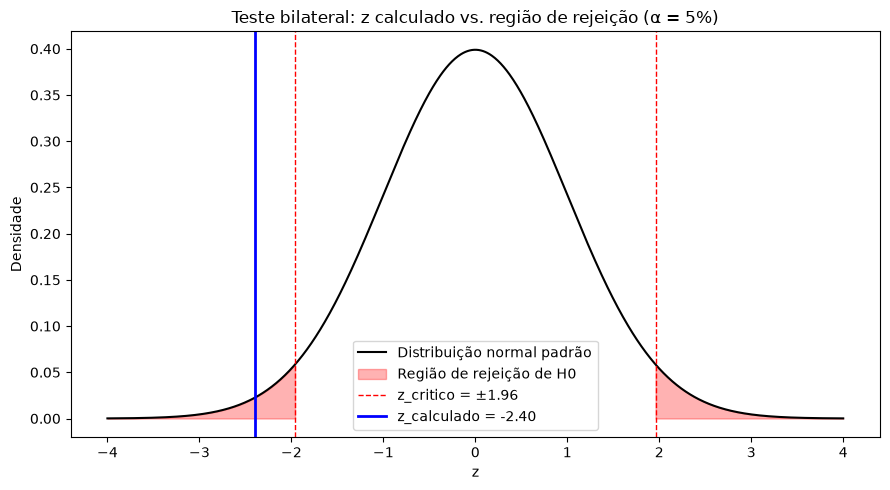

In [6]:
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, y, color="black", linewidth=1.5, label="Distribuição normal padrão")

# Regiões de rejeição (caudas)
x_esq = np.linspace(-4, -z_critico, 200)
x_dir = np.linspace(z_critico, 4, 200)
ax.fill_between(x_esq, stats.norm.pdf(x_esq), color="red", alpha=0.3, label="Região de rejeição de H0")
ax.fill_between(x_dir, stats.norm.pdf(x_dir), color="red", alpha=0.3)

# Linhas verticais: z crítico e z calculado
ax.axvline(-z_critico, color="red", linestyle="--", linewidth=1)
ax.axvline(z_critico, color="red", linestyle="--", linewidth=1, label=f"z_critico = ±{z_critico:.2f}")
ax.axvline(z_calc, color="blue", linestyle="-", linewidth=2, label=f"z_calculado = {z_calc:.2f}")

ax.set_title("Teste bilateral: z calculado vs. região de rejeição (α = 5%)")
ax.set_xlabel("z")
ax.set_ylabel("Densidade")
ax.legend()
plt.tight_layout()
plt.savefig("teste_hipotese_grafico.png", dpi=120)
plt.show()


## 7. Conclusão

Compare os resultados obtidos acima:

| Critério | Valor calculado | Valor de referência | Decisão |
|---|---|---|---|
| Estatística z | \|z\| = 2,40 | z crítico = 1,96 | 2,40 > 1,96 → rejeita H₀ |
| p-valor | 0,0164 | α = 0,05 | 0,0164 < 0,05 → rejeita H₀ |

**Resultado final: rejeita-se H₀.**

Ao nível de significância de α = 5%, há evidência estatística de que **a máquina de envase está
desregulada**. A média amostral (x̄ = 353 ml) está estatisticamente distante do valor especificado
(μ = 355 ml), indicando que o processo provavelmente está enchendo as garrafas com um volume
médio menor do que o esperado — sugerindo a necessidade de calibração/ajuste da máquina.


In [7]:
print("="*60)
print("RESUMO FINAL")
print("="*60)
print(f"H0: mu = {mu0} ml   |   H1: mu != {mu0} ml")
print(f"z_calculado = {z_calc:.4f}")
print(f"z_critico   = ±{z_critico:.4f}")
print(f"p-valor     = {p_valor:.4f}")
print(f"alpha       = {alpha}")
print("-"*60)
conclusao = "REJEITA-SE H0 -> evidência de que a máquina está DESREGULADA" \
    if decisao_z else "NÃO SE REJEITA H0 -> não há evidência de desregulagem"
print(conclusao)
print("="*60)


RESUMO FINAL
H0: mu = 355 ml   |   H1: mu != 355 ml
z_calculado = -2.4000
z_critico   = ±1.9600
p-valor     = 0.0164
alpha       = 0.05
------------------------------------------------------------
REJEITA-SE H0 -> evidência de que a máquina está DESREGULADA
